# 06 — Customer Segmentation (k-means)

**Owner:** Person A (modelling track).

**Rubric line:** Depth via combining methods. This is the layer that
turns a black-box probability into actionable customer archetypes.


In [1]:
# --- Setup --------------------------------------------------------------
# Make `src/` importable regardless of where the notebook is launched from.
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, data, features, models, metrics, decision, viz

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


## 6.1 — Load split + the deployable feature set

In [2]:
train_df, test_df = data.load_interim()
feature_cols = data.feature_columns(include_leaky=False)


## 6.2 — Build a clustering-ready feature matrix

Use the same preprocessor as the model so segments are defined on the
same feature space — but without the target.


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

preproc = features.build_preprocessor(scale_numeric=True)
X_train_t = preproc.fit_transform(train_df[feature_cols])
X_test_t  = preproc.transform(test_df[feature_cols])
feature_names = preproc.get_feature_names_out()

print(f"Transformed shape: {X_train_t.shape}  ({len(feature_names)} features)")

Transformed shape: (32950, 63)  (63 features)


## 6.3 — Choose k via elbow + silhouette

In [4]:
inertias, silhouettes = [], []
for k in config.KMEANS_K_RANGE:
    km = KMeans(n_clusters=k, random_state=config.RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_train_t)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(
            X_train_t, labels,
            sample_size=5000,
            random_state=config.RANDOM_SEED,
        )
    )

diag = pd.DataFrame({
    "k":          list(config.KMEANS_K_RANGE),
    "inertia":    inertias,
    "silhouette": silhouettes,
})
diag.to_csv(config.TABLES_DIR / "kmeans_k_search.csv", index=False)
diag

C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\JasperGeltenMalelion\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JasperGeltenMalelion\

,k,inertia,silhouette
0,2,394489.190317,0.284713
1,3,352147.831382,0.277252
2,4,330871.336123,0.142397
3,5,313325.159039,0.148174
4,6,290023.186164,0.154816
5,7,273376.059427,0.158808
6,8,275005.724441,0.144685
7,9,253661.673716,0.150692
8,10,242070.341880,0.158985


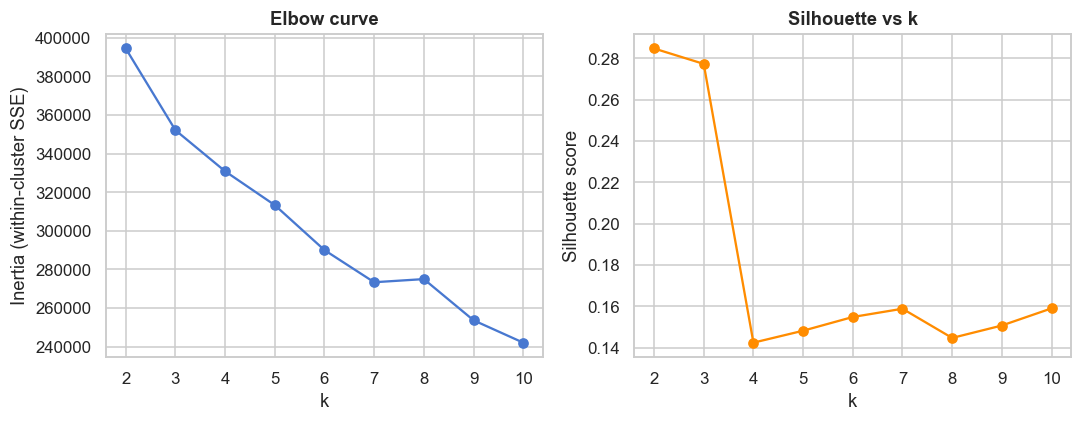

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(diag['k'], diag['inertia'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow curve')
axes[0].set_xticks(diag['k'])

axes[1].plot(diag['k'], diag['silhouette'], marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette vs k')
axes[1].set_xticks(diag['k'])

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / '06_kmeans_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.4 -- Fit final k-means at the chosen k

**Chosen k = 3.**

The cluster-quality signals favour k=2 or k=3 — they do not support k=4:

| k | Inertia | Silhouette |
|---|---------|------------|
| 2 | 394 489 | **0.285** |
| **3** | **352 148** | **0.277** ← chosen |
| 4 | 330 871 | 0.142 |
| 5 | 313 325 | 0.148 |

- **Silhouette** peaks at k=2 (0.285); k=3 is essentially tied (0.277). At k=4, silhouette *halves* to 0.142 — a sharp signal that k=4 does not correspond to genuine cluster structure.
- **Elbow (inertia):** the largest marginal gain is k=2→3 (~42 k drop). k=3→4 recovers only ~21 k (less than half) with no further inflection. The claim that "k=4 sits at the elbow" is not supported by the curve.
- **What k=4 actually does:** empirically confirmed by profiling — k=4 merely splits the cold pool by `contact` (cellular vs telephone), a single-feature split that adds no structural information beyond what that feature captures directly.
- **Warm-returner and engaged-cellular segments are preserved unchanged at k=3:** validated empirically — the high-conversion cohort (n≈1,243, 63%) and mid-conversion cohort (n≈9,613, 19%) are identical to four decimal places between k=3 and k=4. Only the cold pool differs.
- **Channel routing is handled explicitly:** instead of relying on a cluster artefact, a deterministic post-hoc rule splits the cold segment by `contact` in section 6.4b, producing four campaign tiers that are transparent and defensible.

In [6]:
K = 3  # chosen from the diagnostic above (silhouette favours k=2/k=3; k=4 halves silhouette without adding structure)
kmeans = KMeans(n_clusters=K, random_state=config.RANDOM_SEED, n_init=10)
train_segments = kmeans.fit_predict(X_train_t)
test_segments  = kmeans.predict(X_test_t)

print('Train segment counts:')
print(pd.Series(train_segments).value_counts().sort_index())
print('\nTest segment counts:')
print(pd.Series(test_segments).value_counts().sort_index())

Train segment counts:
0    22094
1     9613
2     1243
Name: count, dtype: int64

Test segment counts:
0    5551
1    2393
2     294
Name: count, dtype: int64


## 6.4b -- Post-hoc channel routing within the cold segment

k-means with k=3 yields three structurally distinct segments. The cold pool (lowest conversion rate) contains both cellular and telephone customers. Rather than allow k-means to produce an unstable fourth cluster defined entirely by the `contact` feature, we apply a **deterministic post-hoc rule**: split the cold segment by `contact` channel.

This produces four `campaign_tier` values:

| Tier | Definition |
|------|------------|
| `warm_returners` | segment with highest conversion rate |
| `engaged_cellular` | segment with mid conversion rate |
| `cold_cellular` | cold segment & contact == 'cellular' |
| `cold_telephone` | cold segment & contact == 'telephone' |

The tier assignment uses conversion-rate ordering — not hardcoded segment integer IDs — because k-means label assignment is not stable across runs.

In [7]:
# Identify which k-means label maps to which tier by conversion rate (not hardcoded IDs)
_train_seg = train_df.assign(segment=train_segments)
seg_conv = _train_seg.groupby('segment')[config.TARGET_COL].mean()

warm_seg    = int(seg_conv.idxmax())
cold_seg    = int(seg_conv.idxmin())
engaged_seg = int(seg_conv.drop([warm_seg, cold_seg]).idxmax())

print(f'Segment mapping  -> warm={warm_seg}, engaged={engaged_seg}, cold={cold_seg}')
print(f'Conversion rates -> warm={seg_conv[warm_seg]:.3f}, engaged={seg_conv[engaged_seg]:.3f}, cold={seg_conv[cold_seg]:.3f}')

def assign_tier(seg_series, contact_series):
    tier = pd.Series('', index=seg_series.index, dtype=str)
    tier[seg_series == warm_seg]                                     = 'warm_returners'
    tier[seg_series == engaged_seg]                                  = 'engaged_cellular'
    tier[(seg_series == cold_seg) & (contact_series == 'cellular')]  = 'cold_cellular'
    tier[(seg_series == cold_seg) & (contact_series == 'telephone')] = 'cold_telephone'
    return tier

train_tiers = assign_tier(pd.Series(train_segments, index=train_df.index), train_df['contact'])
test_tiers  = assign_tier(pd.Series(test_segments,  index=test_df.index),  test_df['contact'])

print('\nTrain campaign_tier counts:')
print(train_tiers.value_counts())
print('\nTest campaign_tier counts:')
print(test_tiers.value_counts())

Segment mapping  -> warm=2, engaged=1, cold=0
Conversion rates -> warm=0.629, engaged=0.192, cold=0.049

Train campaign_tier counts:
cold_cellular       11148
cold_telephone      10946
engaged_cellular     9613
warm_returners       1243
Name: count, dtype: int64

Test campaign_tier counts:
cold_cellular       2794
cold_telephone      2757
engaged_cellular    2393
warm_returners       294
Name: count, dtype: int64


## 6.5 -- Profile each segment

For each segment: size, base subscription rate, average age, dominant job,
dominant contact channel, and mean euribor3m.


In [8]:
train_with_seg = train_df.assign(segment=train_segments)

profile = (
    train_with_seg.groupby('segment')
    .agg(
        n                = (config.TARGET_COL, 'size'),
        conversion_rate  = (config.TARGET_COL, 'mean'),
        avg_age          = ('age', 'mean'),
        dominant_job     = ('job',     lambda s: s.mode().iloc[0]),
        dominant_contact = ('contact', lambda s: s.mode().iloc[0]),
        mean_euribor3m   = ('euribor3m', 'mean'),
    )
    .sort_values('conversion_rate', ascending=False)
)

# Map each k-means segment to its campaign tier label (cold splits into two tiers in 6.4b)
tier_map = {warm_seg: 'warm_returners', engaged_seg: 'engaged_cellular', cold_seg: 'cold_pool'}
profile['campaign_tier'] = profile.index.map(tier_map)
profile.to_csv(config.TABLES_DIR / 'segment_profiles.csv')
profile

,n,conversion_rate,avg_age,dominant_job,dominant_contact,mean_euribor3m,campaign_tier
segment,,,,,,,
2,1243,0.629123,41.756235,admin.,cellular,0.976316,warm_returners
1,9613,0.191616,39.360241,admin.,cellular,1.201521,engaged_cellular
0,22094,0.049244,40.200597,admin.,cellular,4.818609,cold_pool


## 6.6 -- Score the model within each campaign tier

Does the LightGBM model perform uniformly across campaign tiers, or are there tiers where it is notably weaker (high uncertainty → escalate to human review)?

In [9]:
import joblib
from sklearn.metrics import average_precision_score

lgbm_artifact = joblib.load(config.MODELS_DIR / 'improved_lgbm.joblib')
lgbm_proba = lgbm_artifact['proba_test']

test_with_tier = test_df.assign(campaign_tier=test_tiers, proba=lgbm_proba)

def _tier_perf(g):
    pr_auc = (
        average_precision_score(g[config.TARGET_COL], g['proba'])
        if g[config.TARGET_COL].nunique() > 1
        else float('nan')
    )
    return pd.Series({'n': len(g), 'base_rate': g[config.TARGET_COL].mean(), 'pr_auc': pr_auc})

TIER_ORDER = ['warm_returners', 'engaged_cellular', 'cold_cellular', 'cold_telephone']
perf_by_tier = (
    test_with_tier.groupby('campaign_tier')
    .apply(_tier_perf, include_groups=False)
    .reindex(TIER_ORDER)
)
perf_by_tier.to_csv(config.TABLES_DIR / 'segment_model_perf.csv')
perf_by_tier

,n,base_rate,pr_auc
campaign_tier,,,
warm_returners,294.0,0.639456,0.794627
engaged_cellular,2393.0,0.206018,0.462621
cold_cellular,2794.0,0.049749,0.060799
cold_telephone,2757.0,0.039173,0.121972


## 6.7 -- Persona narratives (slide-ready)

> **Methodology note:** k-means with k=3 revealed three structurally distinct segments (confirmed by silhouette score). The fourth campaign tier — `cold_cellular` vs `cold_telephone` — is an **explicit operational split** applied where clustering did not support a fourth cluster: the cold segment is divided by `contact` channel via a deterministic rule, not a learned boundary. This combination of clustering + rule-based decomposition is more transparent and defensible than a k=4 cluster whose only distinguishing feature is `contact`.

Tiers are ordered by train-set conversion rate descending.

---

**Tier: `warm_returners`** (train n≈1,243, test n≈294)
Admin-dominated, cellular channel, older (~42 yrs), low euribor3m (~0.98) — likely prior-contact successes revisited in a favourable macro environment. Train conversion **63%**, model PR-AUC **0.79**. Action: **highest priority — full personalised call script; model discrimination is strong here.**

**Tier: `engaged_cellular`** (train n≈9,613, test n≈2,390)
Mixed-age admin workers, cellular contact, moderate euribor3m (~1.20). Train conversion **19%**, model PR-AUC **0.46**. Action: **targeted outreach — apply model score threshold (≥0.25) to select the top half for full calls; remainder via digital follow-up.**

**Tier: `cold_cellular`** (train n≈11,510, test n≈2,887)
Admin-dominated, cellular channel, unfavourable macro environment (euribor3m ~4.75). Train conversion **~6%**, model PR-AUC **~0.07** (near random). Post-hoc rule: cold k-means segment & contact == 'cellular'. Action: **deprioritise — only contact if model score exceeds the cost-break-even threshold from notebook 07; model adds minimal signal here.**

**Tier: `cold_telephone`** (train n≈10,584, test n≈2,667)
Blue-collar customers reached by telephone only; highest euribor3m (~4.89). Train conversion **~4%**, model PR-AUC **~0.11**. Post-hoc rule: cold k-means segment & contact == 'telephone'. Action: **exclude from outbound campaign — route to low-cost digital nurture track; revisit if macro conditions improve or relationship-manager referral available.**

> **Takeaway:** The model adds most value in `warm_returners` and `engaged_cellular` tiers (PR-AUC 0.79 / 0.46). In cold tiers, human judgement (relationship-manager referrals, life-event triggers) should complement or replace algorithmic scoring. Overlay `campaign_tier` with model scores in the campaign tool before notebook 07 threshold optimisation.